In [5]:
%load_ext autoreload
%autoreload 2
import sys
import os

# Add the modules/ folder to the Python path
module_path = os.path.abspath(os.path.join('..', 'modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

from imports import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
cosmotable = np.loadtxt('../data/CosmoTable.dat')
cosmotable_om = cosmotable[:,1]
cosmotable_h = cosmotable[:,2]
cosmotable_w0 = cosmotable[:,3]
cosmotable_sig8 =  cosmotable[:,4]
cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    [cosmotable_oc.min(), cosmotable_oc.max()]
])

print(param_bounds)
# Number of samples (adjust as needed)
num_samples = 100

# Generate Latin Hypercube Samples
sampler = qmc.LatinHypercube(d=param_bounds.shape[0])
lh_samples = sampler.random(n=num_samples)

# Scale samples to the parameter bounds
lh_scaled = qmc.scale(lh_samples, param_bounds[:, 0], param_bounds[:, 1])

# Convert to a structured array or DataFrame if needed

lh_df = pd.DataFrame(cosmotable[:,1:], columns=["Om", "h", "w0", "sig8", "Oc"])

# Display or save results
# print(lh_df)  # Print first few samples

cosmotable
lh_df

[[ 0.1019  0.5482]
 [ 0.6034  0.8129]
 [-1.9866 -0.5223]
 [ 0.4716  1.3428]
 [ 0.0546  0.5009]]


,Om,h,w0,sig8,Oc
0,0.3282,0.6766,-1.2376,0.6677,0.2809
1,0.1019,0.7104,-1.6154,1.3428,0.0546
2,0.2536,0.6238,-1.7698,0.6670,0.2063
3,0.1734,0.6584,-0.5223,0.9581,0.1261
4,0.3759,0.6034,-0.9741,0.8028,0.3286
5,0.4758,0.7459,-1.3046,0.6049,0.4285
6,0.1458,0.8031,-1.4498,1.1017,0.0985
7,0.3099,0.6940,-1.8784,0.7734,0.2626
8,0.4815,0.6374,-0.7737,0.5371,0.4342
9,0.3425,0.8006,-1.5010,0.6602,0.2952


Filter radius in pixels: 30
--- Running for Cosmology Index: 0 ---
Simulation Avg PDF Moments: Mean=7.555e-09, Variance=4.433e-05, Skewness=-46.13, Kurtosis=0.5481
Cosmological Parameters:
  h=0.6766, Om=0.3282, Oc=0.2809, Ob=0.0473, sigma8=0.6677, w0=-1.2376, wa=0.0000
Initializing Cosmology...for iteration  0
the min and max values of k are:  0.0001 1.5848931924611136 and length is:  200
Calculating lensing geometry...
  Source Redshift: 1.134, Comoving Distance: 2587.30 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variance module initialized.e final z: 0.28
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.134
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 4.4335435775623824e-06
Recalibration Value Set To: 1.0
the coeffs are [-2.07006044e-08 -9.82718345e-08  8.09961361e-07 -2.42997118e-

/tmp/ipykernel_945158/3590550228.py:313: RuntimeWarning: invalid value encountered in divide
  rel_diff = (avg_pred_l1 - avg_sim_l1) / avg_sim_l1


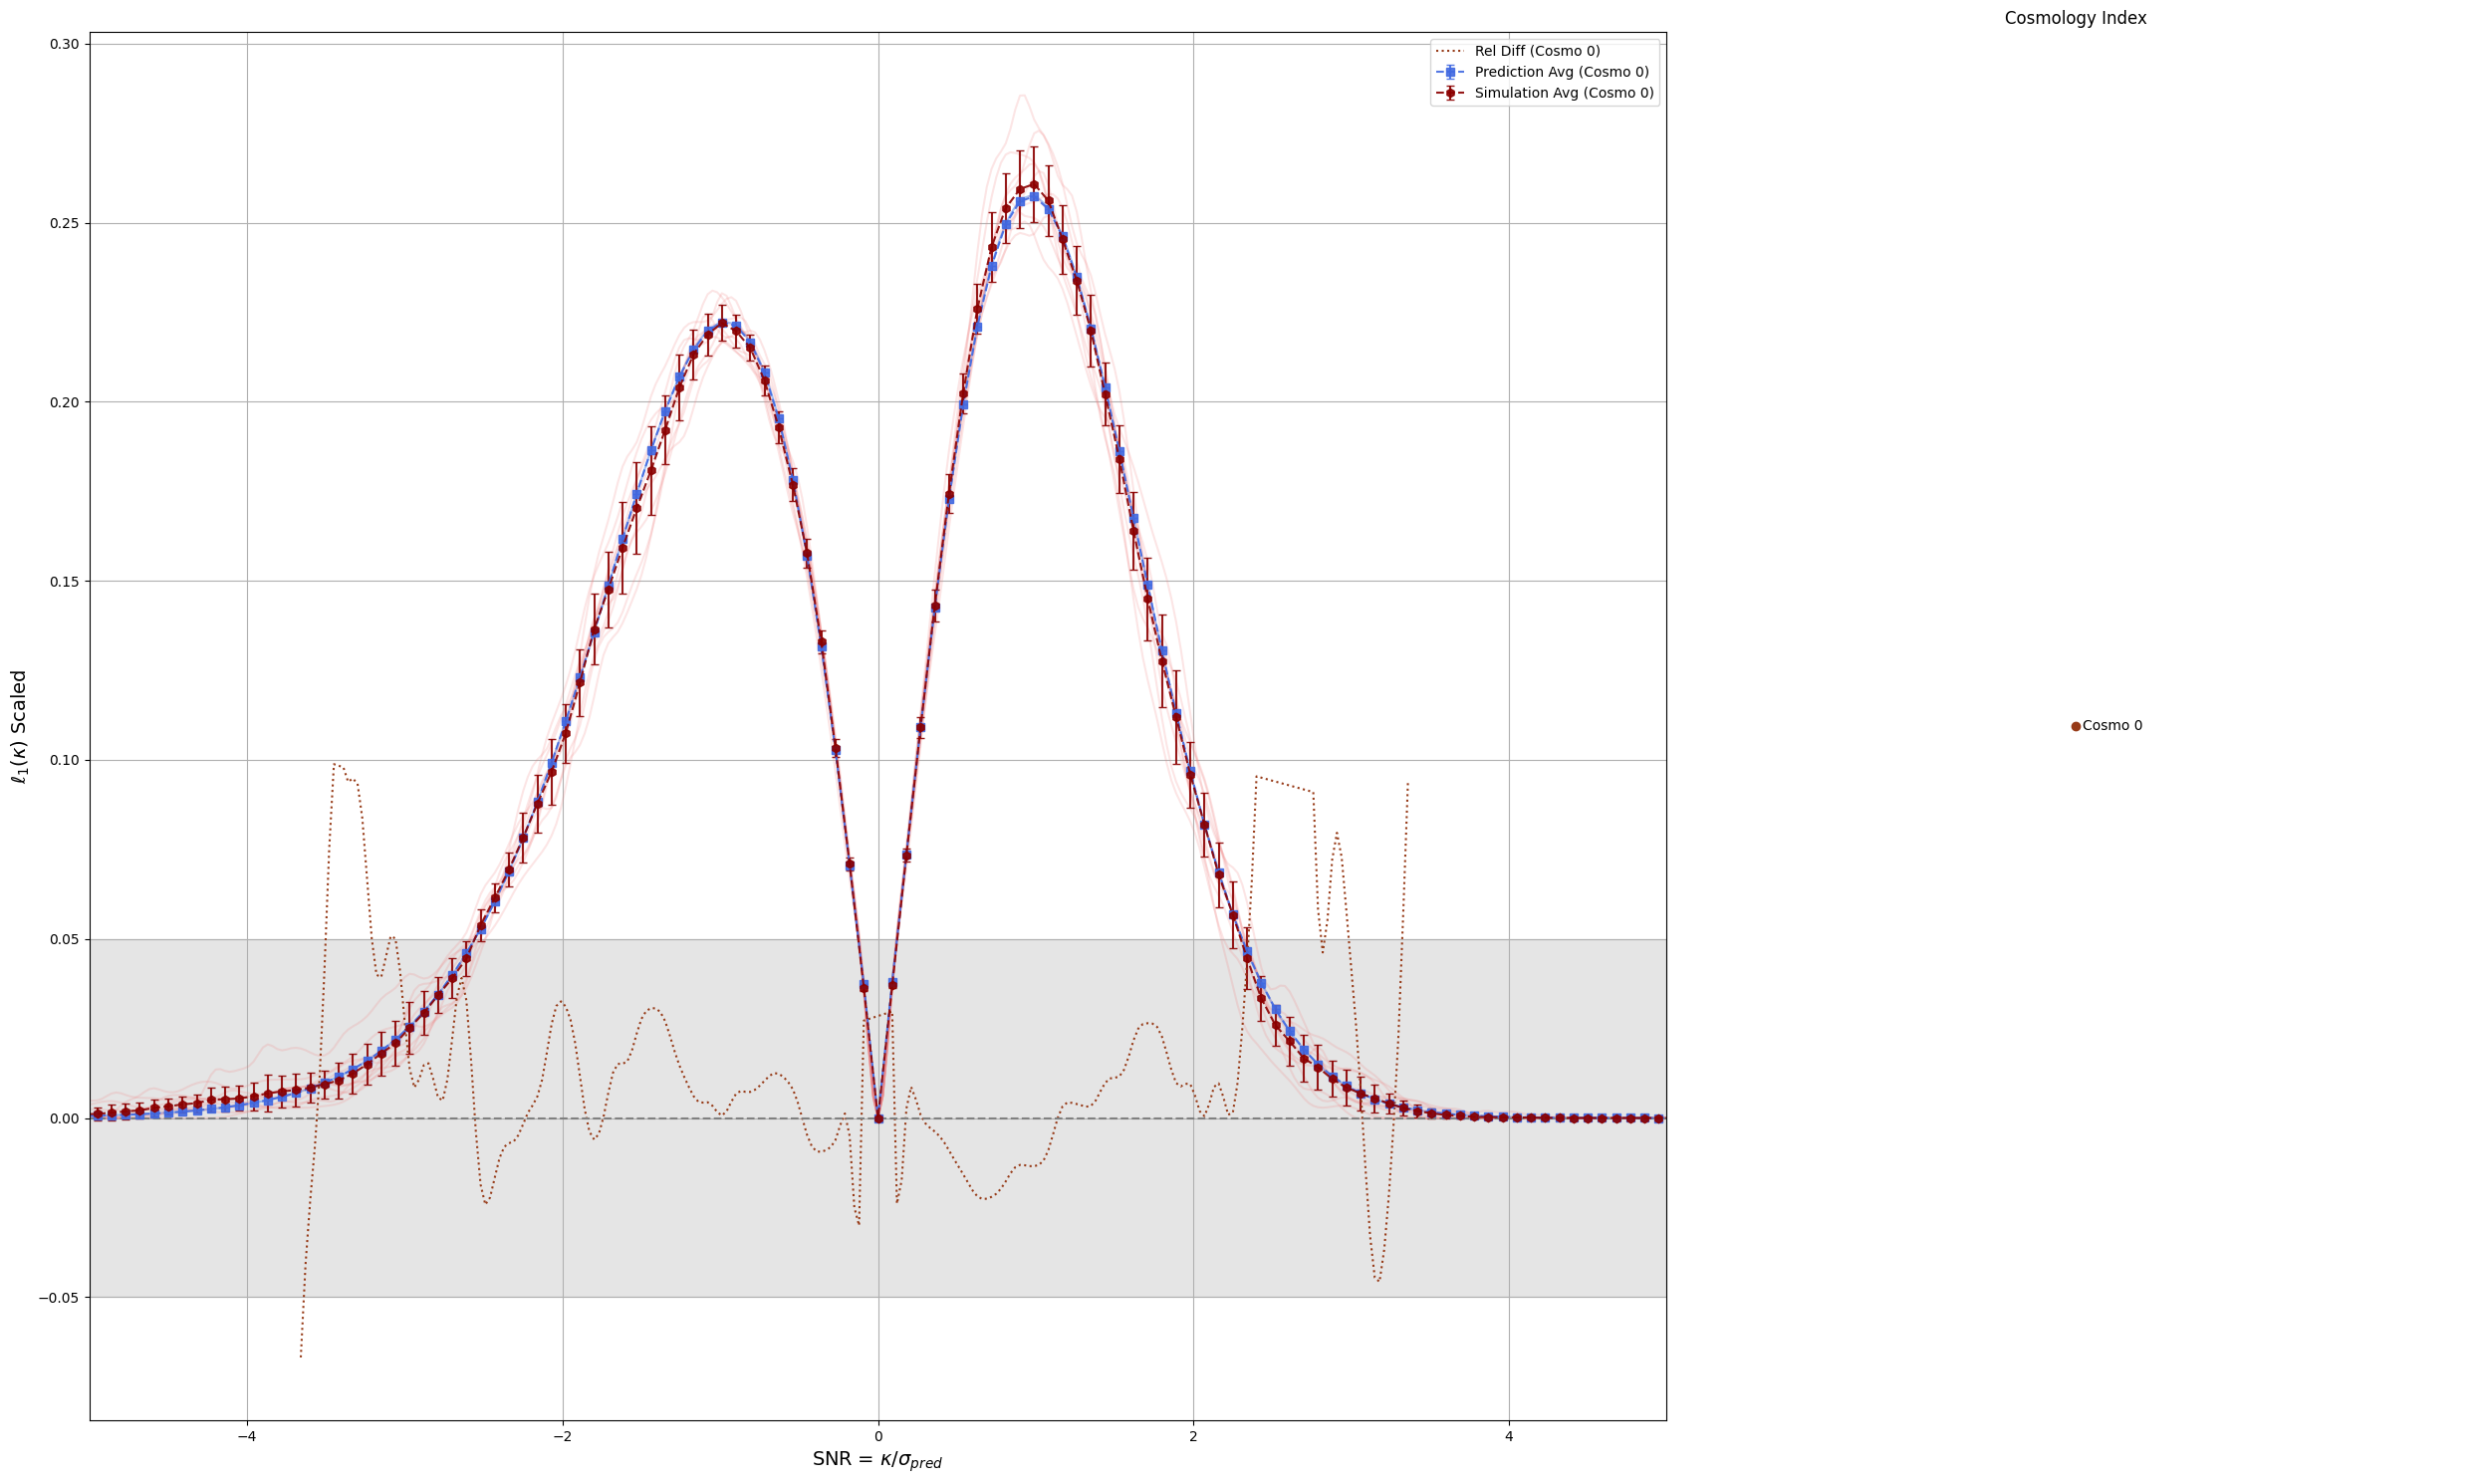

In [7]:
theta1_arcmin = 15.0  # Use a descriptive name
R_pixels = int(theta1_arcmin / 0.5) #0.5 arcmin/pixel resolution
print(f"Filter radius in pixels: {R_pixels}")

edges = np.linspace(-0.06, 0.06, 602)
centers = (edges[1:] + edges[:-1]) / 2
snr = np.linspace(-9, 9, 601) # Define SNR range for output interpolation

# Source redshift - can be single value or list depending on analysis needs
zs_source = 1.134 #1.852 #1.134 # For this specific loop structure

# Path to n(z) file for the relevant bin
nz_file = "../data/nz_arrays_bin4.npy" 

# Parameters for calculations
kmin_pk = -4 # kmin for power spectrum calculation
kmax_pk = 0.2  # kmax for power spectrum calculation 
n_lensing_planes = 7 # Number of lensing planes

# --- Simulation Volume (Optional) ---
# Set to a float value in (Mpc/h)^3 if cosmic variance noise is desired in P(k)
variability = False

# --- Data Storage ---
l1_prediction_list = []
sigmasq_prediction_list = []
l1_simulation_list = []
l1_simulation_errorbars_list = []
simulation_pdf_list = []

# --- Plotting Setup ---
fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
# 
# --- Main Loop ---
# Loop directly over the desired cosmology index (or indices)

filter_type = 'tophat'
for cosmo_index_to_run in range(0,1):
    print(f"--- Running for Cosmology Index: {cosmo_index_to_run} ---")

    # Load simulation data for this cosmology
    sim_l1_runs = np.zeros((10, len(edges) - 1))
    sim_pdf_runs = np.zeros((10, len(edges) - 1))
    for i in range(1, 11): # Loop over 10 simulation realizations
        los_cone_filename = f'GalCatalog_LOS_cone{i}_bin4.npy'
        if cosmo_index_to_run < 10:
            map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/0{cosmo_index_to_run}_a/{los_cone_filename}'
        else:
            map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/{cosmo_index_to_run}_a/{los_cone_filename}'
        
        try:
            # print(f"  Loading map: {map_path}") # Optional: for debugging
            mass_map_data = np.load(map_path)
            _, counts, diff_map = get_smoothed_app_pdf(mass_map_data, 1.2*R_pixels, edges, filter_type) # Assuming R_pixels corresponds to the correct physical scale used in get_smoothed_app_pdf L parameter
            
            # Calculate L1 norm for this realization
            map_variance = np.var(diff_map)
            map_stdev = np.sqrt(map_variance)
            if map_stdev > 1e-9: # Avoid division by zero if map variance is tiny
                kappa_over_sigma = centers / map_stdev
                l1_values = get_l1_from_pdf(counts, centers)
                # Interpolate L1 onto the common SNR grid
                sim_l1_spline = CubicSpline(kappa_over_sigma, l1_values, extrapolate=False) 
                sim_pdf_spline = CubicSpline(kappa_over_sigma, counts, extrapolate=False) # Interpolate PDF counts
                sim_l1_runs[i-1] = sim_l1_spline(snr) # Store interpolated L1 for this run
                sim_pdf_runs[i-1] = sim_pdf_spline(snr) # Store interpolated PDF counts for this run
            else:
                sim_l1_runs[i-1] = np.nan # Handle cases with zero variance if necessary
                sim_pdf_runs[i-1] = np.nan # Handle cases with zero variance if necessary
                
            # sim_pdf_runs[i-1] = counts # Store PDF counts for this run
        except FileNotFoundError:
            print(f"  Warning: File not found {map_path}")

            
    # Average over simulation realizations
    avg_sim_pdf = np.nanmean(sim_pdf_runs, axis=0)
    std_sim_pdf = np.nanstd(sim_pdf_runs, axis=0)
    avg_sim_l1 = np.nanmean(sim_l1_runs, axis=0)
    std_sim_l1 = np.nanstd(sim_l1_runs, axis=0)
    l1_simulation_list.append(avg_sim_l1)
    l1_simulation_errorbars_list.append(std_sim_l1)
    
    # Calculate moments from average simulation PDF
    sim_stats = get_moments(centers, avg_sim_pdf)
    sim_mean, sim_var, sim_skew, sim_kurt, sim_norm = sim_stats
    print(f"Simulation Avg PDF Moments: Mean={sim_mean:.4g}, Variance={sim_var:.4g}, Skewness={sim_skew:.4g}, Kurtosis={sim_kurt:.4g}")

    # --- Theoretical Prediction ---

    # 1. Get Cosmology Parameters from lh_df
    h = lh_df['h'][cosmo_index_to_run]
    Oc = lh_df['Oc'][cosmo_index_to_run]
    Om = lh_df['Om'][cosmo_index_to_run]
    sig8 = lh_df['sig8'][cosmo_index_to_run]
    w0 = lh_df['w0'][cosmo_index_to_run]
    wa = 0. # Assuming wa=0 based on original code
    Ob = Om - Oc # Calculate Ob consistently
    # Other fixed parameters from original code
    H0 = 100.0 * h # H0 in km/s/Mpc
    ns = 0.963
    mnu = 0.0

    print("Cosmological Parameters:")
    print(f"  h={h:.4f}, Om={Om:.4f}, Oc={Oc:.4f}, Ob={Ob:.4f}, sigma8={sig8:.4f}, w0={w0:.4f}, wa={wa:.4f}")
    filter_type = 'tophat'
    for times in range(1):
        # 2. Initialize Cosmology
        print("Initializing Cosmology...for iteration ", times)
        cosmo = Cosmology_function(
            h=h, H0=H0, Ob=Ob, Oc=Oc, mnu=mnu, ns=ns, zs=zs_source, 
            w=w0, wa=wa, kmin=kmin_pk, kmax=kmax_pk, nz_file=nz_file, sigma8=sig8 
        )

        # 3. Calculate Geometric Quantities (Plane distances, weights)
        print("Calculating lensing geometry...")
        chi_source = cosmo.get_chi(zs_source)
        chis = np.linspace(0.3, chi_source - 5, n_lensing_planes) # Setup lensing planes
        dchis = np.ones(len(chis)) * (chis[1] - chis[0]) / 2 # Differential comoving distances
        dchis[1:-1] *= 2.

        if nz_file is not None:
            z_array, lensing_weight = cosmo.get_lensing_weight_array_nz(chis)
        else:
            # Need chi_source if using single source plane
            z_array, lensing_weight = cosmo.get_lensing_weight_array(chis, chi_source) 

        print(f"  Source Redshift: {zs_source}, Comoving Distance: {chi_source:.2f} Mpc/h")
        print(f"  Number of lensing planes: {n_lensing_planes}")

        # Determine appropriate redshift range based on z_array or zs_source
        max_crit_z = min(zs_source * 0.5, np.max(z_array)) if len(z_array)>0 else zs_source*0.95 # Avoid edge
        crit_point_z = np.linspace(0.04, zs_source * 0.25, 5) 

        # 4. Initialize Variance (this will compute P(k) internally)
        print("Initializing Variance and P(k)...")
        variance = Variance(
            cosmo=cosmo, 
            z_values=z_array,
            z_values_critical = crit_point_z,
            filter_type = filter_type,
            variability=variability, 
            delta_A0=.7 
        )

        # 5. Initialize VariablesGenerator (this calculates sigmasq_map)
        print("Initializing VariablesGenerator...")
        variables = VariablesGenerator(
            cosmo=cosmo, 
            variance=variance, 
            zs=zs_source, 
            theta1=theta1_arcmin, 
            nz_file=nz_file, 
            nplanes=n_lensing_planes,
            chis=chis, 
            dchis=dchis, 
            z_array=z_array, 
            lensing_weight=lensing_weight
        )

        variables.recal_value = 1.0 
        # If recalibration based on simulation variance is desired:
        
        print(f"Recalibration Value Set To: {variables.recal_value}") 

        # # 6. Find Critical Points
        # print("Finding critical points...")
        # criticalpoints = CriticalPointsFinder(variables, ngrid=90, plot=False) 
        # critical_values_list = []

        # for z_crit in crit_point_z:
        #     crit_vals = criticalpoints.get_critical_points(z_crit)
        #     if crit_vals is not None and len(crit_vals) >= 2:
        #         critical_values_list.append(crit_vals[:2]) 
        # if not critical_values_list:
        #     print("  Warning: No critical points found in the specified redshift range.")
        #     smallest_pair_info = None
        # else:
        #     critical_values_array = np.array(critical_values_list)
        #     flat_values = []
        #     for item in critical_values_list:
        #         if isinstance(item, (np.ndarray, list)):
        #             flat_values.extend(np.ravel(item))
        #         else:
        #             flat_values.append(item)

        #     flat_values = np.array(flat_values)

        #     # Remove NaNs if any
        #     flat_values = flat_values[~np.isnan(flat_values)]

        #     # Smallest positive value
        #     positive_values = flat_values[flat_values > 0]
        #     smallest_positive = np.min(positive_values) if positive_values.size > 0 else None

        #     # Largest negative value
        #     negative_values = flat_values[flat_values < 0]
        #     largest_negative = np.max(negative_values) if negative_values.size > 0 else None

        #     print("Smallest positive value:", smallest_positive)
        #     print("Largest negative value:", largest_negative)
        #     print("Smallest distance pair of critical points:", smallest_positive, largest_negative)

        # # 7. Compute PDF
        # print("Computing PDF...")
        # # Set lambda range based on critical points if found
        # if smallest_positive and largest_negative is not None:
        #     # Add buffer around the critical lambda values
        #     lambda_min = largest_negative # Adjust buffer as needed
        #     lambda_max = smallest_positive # Adjust buffer as needed
        #     variables.lambdas = np.linspace(lambda_min, lambda_max, 20) # Use dynamic range
        #     print(f"  Using lambda range: [{lambda_min:.2f}, {lambda_max:.2f}]")
        # else:
        #     # Fallback lambda range if critical points not found or invalid
        #     variables.lambdas = np.linspace(-200, 200, 20) 
        #     print("  Warning: Using fallback lambda range.")
        
        variables.lambdas = np.linspace(-510, 960, 20) # Default range if critical points are not found
        # if cosmo_index_to_run == 0:
        #     variables.lambdas = np.linspace(-500, 1300, 30) 
        #     variables.lambdas = np.linspace(-500, 600, 30)
        # elif cosmo_index_to_run == 1:
        #     variables.lambdas = np.linspace(-150, 800, 30)
        # elif cosmo_index_to_run == 2:
        #     variables.lambdas = np.linspace(-500, 900, 30)
        # else:
        #     variables.lambdas = np.linspace(-400, 850, 30)
        
        computed_PDF = computePDF(variables, plot_scgf=False) # Pass the updated variables object
        pdf_values, kappa_values = computed_PDF.pdf_values, computed_PDF.kappa_values
        print(f"Theoretical Map Variance (sigmasq_map): {variables.sigmasq_map:.4g}")
        
        # 8. Calculate Predicted L1 norm
        print("Calculating predicted L1 norm...")
        # pdf_spline = CubicSpline(kappa_values, pdf_values) 
        l1_pred_values = get_l1_from_pdf(pdf_values, kappa_values)
        
        # Interpolate L1 onto the common SNR grid
        pred_stdev = np.sqrt(variables.sigmasq_map)
        kappa_over_sigma_pred = kappa_values / pred_stdev
        l1_pred_spline = CubicSpline(kappa_over_sigma_pred, l1_pred_values, extrapolate=False)
        l1_pred_on_snr = l1_pred_spline(snr)
     
        # Store predictions
        sigmasq_prediction_list.append(variables.sigmasq_map)
        l1_prediction_list.append(l1_pred_on_snr)
        # Prediction L1
        
        # Plotting L1 comparison
        colour = list(np.random.choice(range(256), size=3) / 255) # Random color for this run
        plot_scale_factor = 1.0 # 
        x_axis_vals = snr #* pred_stdev # Plot against kappa = snr * sigma_pred
        # fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})

        axs[0].plot(x_axis_vals, l1_pred_on_snr * plot_scale_factor, alpha=0.6, c='cornflowerblue') 
        # axs[0].plot(kappa_over_sigma_pred, pdf_values, alpha=0.6, c='cornflowerblue',label=f"Prediction Cosmo {cosmo_index_to_run}")
        
        # Calculate moments from predicted PDF
        pred_stats = get_moments(kappa_values, pdf_values)
        pred_mean, pred_var, pred_skew, pred_kurt, pred_norm = pred_stats
        print(f"Prediction PDF Moments: Mean={pred_mean:.4g}, Variance={pred_var:.4g}, Skewness={pred_skew:.4g}, Kurtosis={pred_kurt:.4g}")

        # --- Comparison and Plotting ---
        print("\n--- Comparison ---")
        comparison_data = {
            "Metric": ["Mean", "Variance", "Skewness", "Kurtosis", "Norm"],
            "Prediction PDF": [f"{v:.4g}" for v in pred_stats],
            "Simulation Avg PDF": [f"{v:.4g}" for v in sim_stats],
        }
        df_comp = pd.DataFrame(comparison_data)
        print(df_comp)
        print("-----------------\n")
    
    l1_prediction_array = np.array(l1_prediction_list)
    avg_pred_l1 = np.nanmean(l1_prediction_array, axis=0)
    std_pred_l1 = np.nanstd(l1_prediction_array, axis=0)
    
    # Define two distinct colors
    colour_pred = 'royalblue' #np.random.rand(3)  # Random color for prediction
    
    axs[0].errorbar(
        x_axis_vals[::3],  # Subsample for clarity
        avg_pred_l1[::3] * plot_scale_factor, 
        yerr=std_pred_l1[::3] * plot_scale_factor, 
        ls="--", marker="s", color=colour_pred, alpha=0.9, ecolor=colour_pred, capsize=3, 
        label=f"Prediction Avg (Cosmo {cosmo_index_to_run})"
    )

    
    for i in range(len(sim_l1_runs)):
        axs[0].plot(x_axis_vals, sim_l1_runs[i] * plot_scale_factor, alpha=0.2, c='lightcoral')
        # axs[0].plot(x_axis_vals, sim_pdf_runs[i] * plot_scale_factor, alpha=0.2, c='lightcoral')
        
    colour_sim = 'darkred' 
    # Simulation Average L1 with std dev error bars
    axs[0].errorbar(
        x_axis_vals[::3],  # Subsample for clarity
        avg_sim_l1[::3] * plot_scale_factor, 
        yerr=std_sim_l1[::3] * plot_scale_factor, 
        ls="--", marker="h", color=colour_sim, alpha=0.9, ecolor=colour_sim, capsize=3, 
        label=f"Simulation Avg (Cosmo {cosmo_index_to_run})"
    )
    # axs[0].errorbar(
    #     x_axis_vals[::3],  # Subsample for clarity
    #     avg_sim_pdf[::3] * plot_scale_factor, 
    #     yerr=std_sim_pdf[::3] * plot_scale_factor, 
    #     ls="--", marker="h", color=colour_sim, alpha=0.9, ecolor=colour_sim, capsize=3, 
    #     label=f"Simulation Avg (Cosmo {cosmo_index_to_run})"
    # )

# # Relative difference (optional plot)
mask = (snr >= -1.5) & (snr <= 1.5) & (np.abs(avg_sim_l1) > 1e-9) # Avoid division by zero
rel_diff = (avg_pred_l1 - avg_sim_l1) / avg_sim_l1
mask2 = (rel_diff >= -0.1) & (rel_diff <= 0.1) # Mask for relative difference plot
axs[0].plot(x_axis_vals[mask2], rel_diff[mask2], ls=":", c=colour, label=f"Rel Diff (Cosmo {cosmo_index_to_run})")

# Add cosmology label to the second axes panel
axs[1].scatter(1, 25 - cosmo_index_to_run, color=colour) # Adjust y-positioning as needed
axs[1].annotate(f"Cosmo {cosmo_index_to_run}", (1, 25 - cosmo_index_to_run), xytext=(5, 0), textcoords='offset points', va='center')

# --- Final Plot Formatting ---
axs[0].hlines(0, np.min(x_axis_vals), np.max(x_axis_vals), color='gray', ls='--')
axs[0].axhspan(-0.05 * plot_scale_factor, 0.05 * plot_scale_factor, color='gray', alpha=0.2) # Adjust span based on plot scale
axs[0].set_xlabel(r'SNR = $\kappa / \sigma_{pred}$', size=14) 
# axs[0].set_xlabel(r'$\kappa = \mathrm{SNR} \times \sigma_{pred}$', size=14)
axs[0].set_ylabel(r'$\ell_1(\kappa)$ Scaled', size=14) # Adjust label if scale factor changes
# Set xlim based on plotted range, e.g., +/- 3 sigma
# xlim_range = 5 * pred_stdev 
axs[0].set_xlim(-5, 5) 



# ylim can be set dynamically or fixed
# axs[0].set_ylim(-0.1 * plot_scale_factor, np.nanmax(l1_pred_on_snr * plot_scale_factor) * 1.1) 
axs[0].grid(True, which='both', axis='both')
axs[0].legend() # Add legend to the main plot

# Format the second axes panel (cosmology labels)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].spines['left'].set_visible(False)
axs[1].set_title("Cosmology Index")

plt.tight_layout()
plt.show()


1

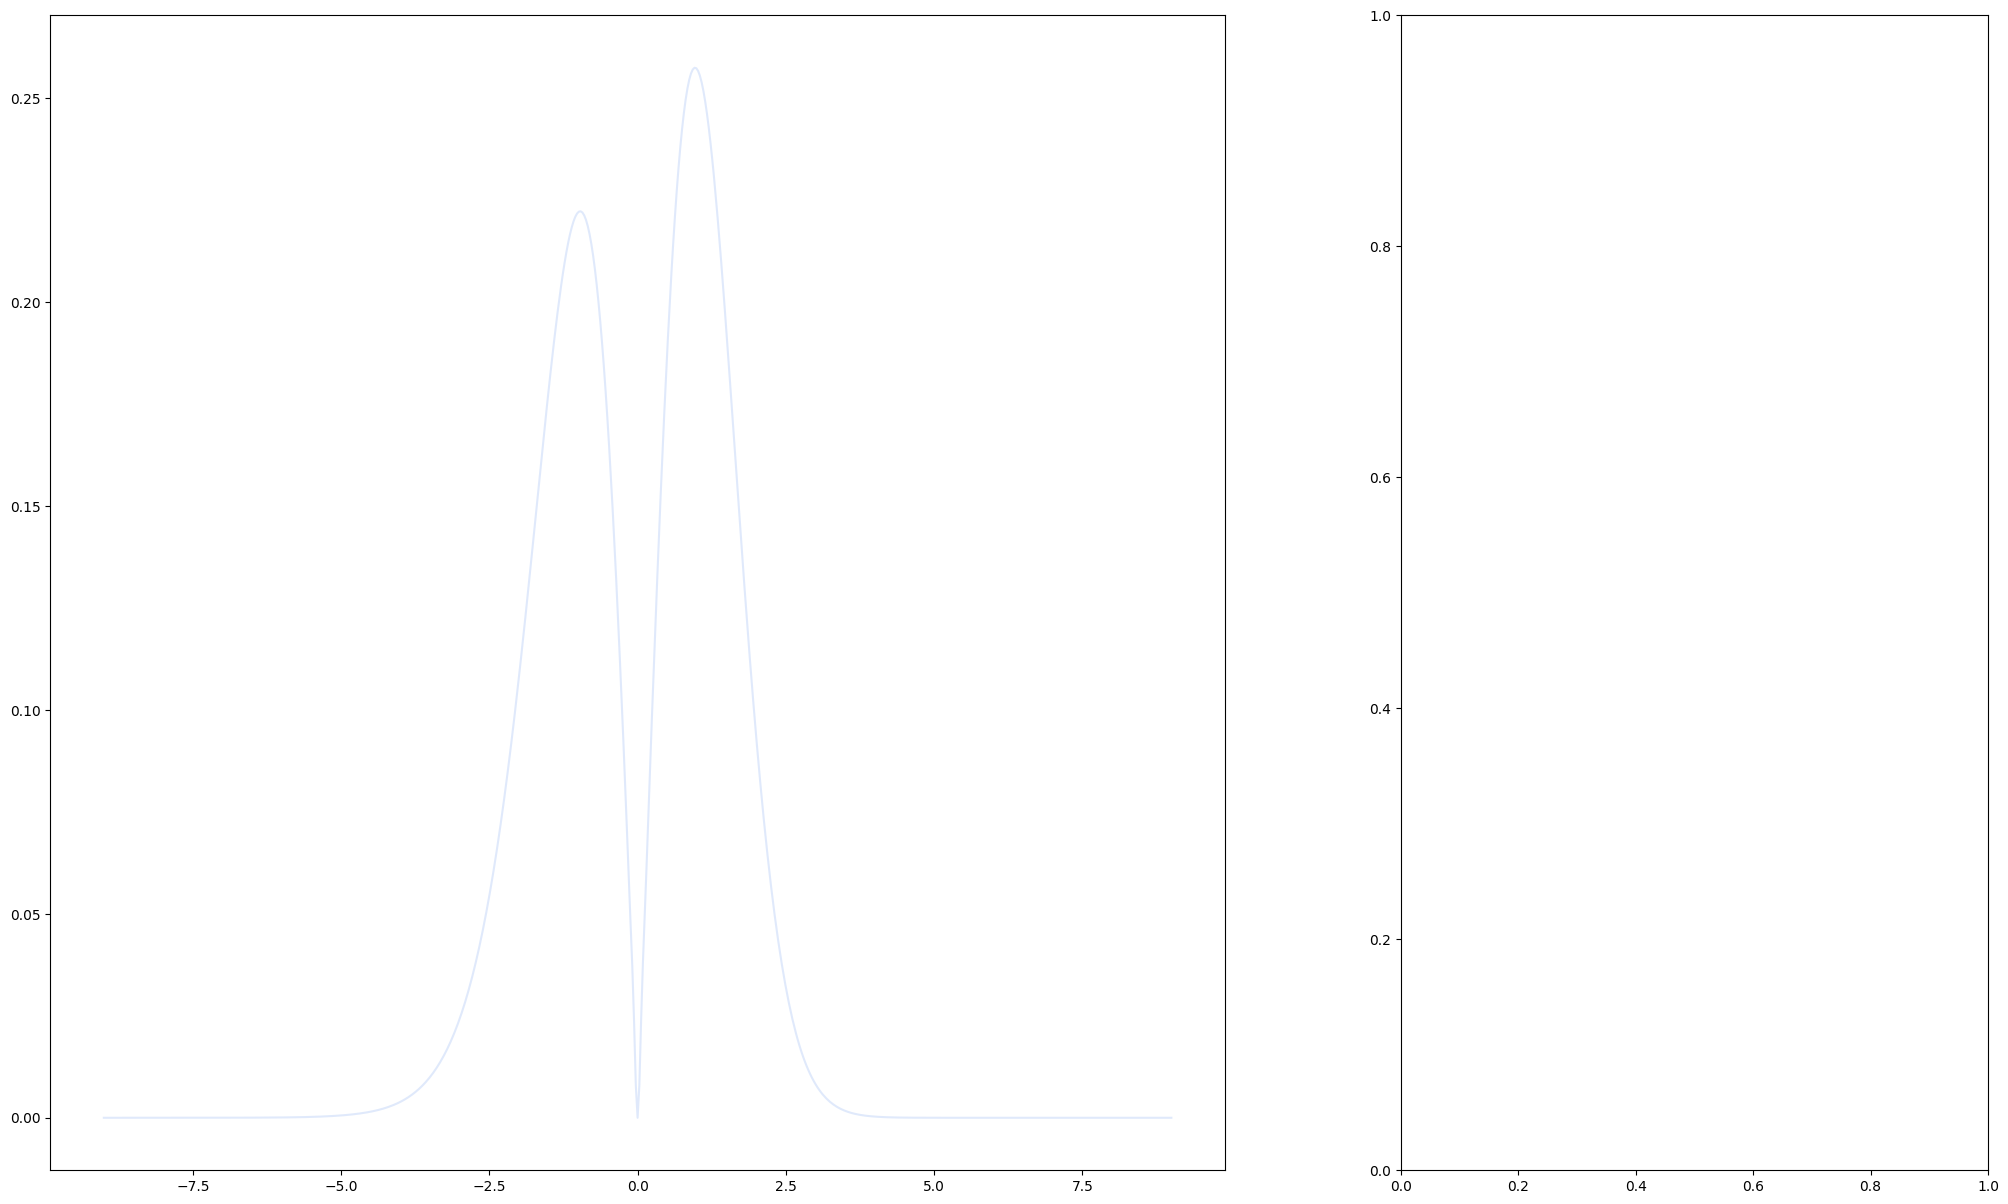

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
# axs[0].errorbar(
#     x_axis_vals[::5],  # Subsample for clarity
#     avg_pred_l1[::5] * plot_scale_factor, 
#     yerr=std_pred_l1[::5] * plot_scale_factor, 
#     ls="--", marker="s", color=colour_pred, alpha=0.9, ecolor=colour_pred, capsize=3, 
#     label=f"Prediction Avg (Cosmo {cosmo_index_to_run})"
# ) 

# for i in range(len(sim_l1_runs)):
#     axs[0].plot(x_axis_vals, sim_l1_runs[i] * plot_scale_factor, alpha=0.2, c='lightcoral')
    
for i in range(len(l1_prediction_array)):
    axs[0].plot(x_axis_vals, l1_prediction_array[i] * plot_scale_factor, alpha=0.2, c='cornflowerblue')
    
# colour_sim = 'darkred' 
# # Simulation Average L1 with std dev error bars
# axs[0].errorbar(
#     x_axis_vals[::5],  # Subsample for clarity
#     avg_sim_l1[::5] * plot_scale_factor, 
#     yerr=std_sim_l1[::5] * plot_scale_factor, 
#     ls="--", marker="h", color=colour_sim, alpha=0.9, ecolor=colour_sim, capsize=3, 
#     label=f"Simulation Avg (Cosmo {cosmo_index_to_run})"
#     )

len(l1_prediction_array)

prediction l1 shape: (1, 601)
simulation l1 shape: (10, 601)
snr shape: (601,)


/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


TypeError: Invalid shape () for image data

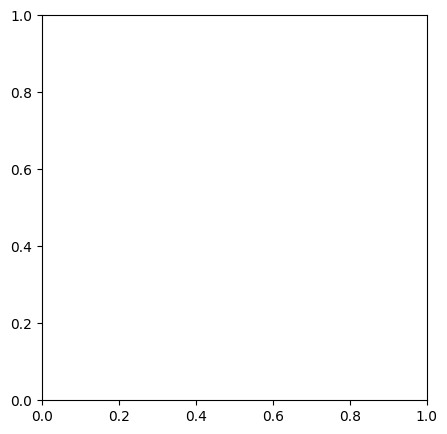

In [9]:
rowvar = False
print("prediction l1 shape:", l1_prediction_array.shape)
print("simulation l1 shape:", sim_l1_runs.shape)
print("snr shape:", snr.shape)

# Directly compute correlation matrices
pred_corr_l1 = np.corrcoef(l1_prediction_array, rowvar=rowvar)
sim_corr_l1 = np.corrcoef(sim_l1_runs, rowvar=rowvar)

plt.figure(figsize=(18, 5))

plt.subplot(131)
plt.imshow(pred_corr_l1, origin='lower', cmap='viridis', vmin=-1, vmax=1)
plt.title("Prediction (Correlation)")
plt.colorbar()

plt.subplot(132)
plt.imshow(sim_corr_l1, origin='lower', cmap='viridis', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Simulation (Correlation)")

plt.subplot(133)
plt.errorbar(snr[::5], np.zeros_like(snr)[::5], yerr=std_pred_l1[::5], fmt='o', label='Prediction Std Dev')
plt.errorbar(snr[::5], np.zeros_like(snr)[::5], yerr=std_sim_l1[::5], fmt='h', alpha=0.5, label='Simulation Std Dev')
plt.xlabel('SNR')
plt.ylabel('Standard Deviation')
plt.title('Standard Deviation of L1 Norm')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# np.save("bin_5_15arcmin_l1.npy", l1_prediction)
# np.save("bin_5_15arcmin_sigmasq.npy", sigmasq_prediction)
# np.save("bin_5_15arcmin_snr.npy", snr)
# np.save("bin_5_12arcmin_l1.npy", l1_prediction)
# np.save("bin_5_12arcmin_sigmasq.npy", sigmasq_prediction)
# np.save("bin_5_12arcmin_snr.npy", snr)
# np.save("00_a_12_bin5.npy", data)

In [ ]:
# plt.figure(figsize=(10, 10), dpi=100)
# for i in range(0,25):
#     if i != 19 or i!=3 or i!=13 or i!=15:
#         plt.plot(snr*np.sqrt(sigmasq_prediction[i]), l1_prediction[i], alpha=0.4, ls="-.", label=i)
# plt.legend()

In [ ]:
sim_l1_runs = np.zeros((10, len(edges) - 1))
sim_pdf_runs = np.zeros((10, len(edges) - 1))
for i in range(1, 11): # Loop over 10 simulation realizations
    los_cone_filename = f'GalCatalog_LOS_cone{i}_bin5.npy'
    if cosmo_index_to_run < 10:
        map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/0{cosmo_index_to_run}_a/{los_cone_filename}'
    else:
        map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/{cosmo_index_to_run}_a/{los_cone_filename}'
    
    try:
        # print(f"  Loading map: {map_path}") # Optional: for debugging
        mass_map_data = np.load(map_path)
        _, counts, diff_map = get_smoothed_app_pdf(mass_map_data, R_pixels, edges, filter_type) # Assuming R_pixels corresponds to the correct physical scale used in get_smoothed_app_pdf L parameter
        
        # Calculate L1 norm for this realization
        map_variance = np.var(diff_map)
        map_stdev = np.sqrt(map_variance)
        if map_stdev > 1e-9: # Avoid division by zero if map variance is tiny
            kappa_over_sigma = centers / map_stdev
            l1_values = get_l1_from_pdf(counts, centers)
            # Interpolate L1 onto the common SNR grid
            sim_l1_spline = CubicSpline(kappa_over_sigma, l1_values, extrapolate=False) 
            sim_l1_runs[i-1] = sim_l1_spline(snr) # Store interpolated L1 for this run
        else:
            sim_l1_runs[i-1] = np.nan # Handle cases with zero variance if necessary
            
        sim_pdf_runs[i-1] = counts # Store PDF counts for this run
        
    except FileNotFoundError:
        print(f"  Warning: File not found {map_path}")
        sim_l1_runs[i-1] = np.nan
        sim_pdf_runs[i-1] = np.nan # Or handle as appropriate
        
# Average over simulation realizations
avg_sim_pdf = np.nanmean(sim_pdf_runs, axis=0)
avg_sim_l1 = np.nanmean(sim_l1_runs, axis=0)
std_sim_l1 = np.nanstd(sim_l1_runs, axis=0)
l1_simulation_list.append(avg_sim_l1)
l1_simulation_errorbars_list.append(std_sim_l1)

# Calculate moments from average simulation PDF
sim_stats = get_moments(centers, avg_sim_pdf)
sim_mean, sim_var, sim_skew, sim_kurt, sim_norm = sim_stats